In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Import the data
df = pd.read_csv('general_error_rank_bench.csv')

## Error numerical experiment

Data filtering

In [5]:
omega=0.1

filtered_df= df[(df["omega"]==omega)]
filtered_df=filtered_df[['eps','err','err_naive_0','err_tight_0','err_naive_1','err_tight_1','eps_norm']]

Code

In [9]:
import matplotlib.pyplot as plt

# === Figure size (inches) ===
width_in = 150 / 25.4  # 150 mm
height_in = (width_in)/2 * 0.75 +0.5

# === Thesis-style settings ===
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
})

# === Create two subplots without shared x-axis ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width_in, height_in))

# === Styles ===
markers = ['o', 's', 'd', 's', 'd', '*']
colors = ['k', 'g', 'r', 'c', 'm', 'k']
linestyles = ['-', ':', ':', '-.', '-.', '--']

error_cols = ['err', 'err_naive_0', 'err_tight_0', 'err_naive_1', 'err_tight_1', 'eps_norm']
rank_cols  = ['rk',  'rk_naive_0', 'rk_tight_0',  'rk_naive_1',  'rk_tight_1',  'eps_norm']

label_map = {
    'err': '$SVD_{{gesdd}}$',
    'err_naive_0': '$HASVD_{{dist,hierarchical}}$',
    'err_tight_0': '$HASVD_{{dist,flat}}$',
    'err_naive_1': '$HASVD_{{inc,hierarchical}}$',
    'err_tight_1': '$HASVD_{{inc,flat}}$',
    'rk': '$SVD_{{gesdd}}$',
    'rk_naive_0': '$HASVD_{{dist,hierarchical}}$',
    'rk_tight_0': '$HASVD_{{dist,flat}}$',
    'rk_naive_1': '$HASVD_{{inc,hierarchical}}$',
    'rk_tight_1': '$HASVD_{{inc,flat}}$',
    'eps_norm': r'$\epsilon^*\|A\|_{F}$ (prescribed)',
}

xlabel = r'Prescribed $\epsilon^*$'
ylabel_error = r'Mean Frobenius error $\epsilon$'
ylabel_rank = r'Mean matrix rank $r$'

# === Filtered data ===
omega = 0.1
filtered_df = df[df["omega"] == omega]

# === Frobenius Error Plot ===
for i, col in enumerate(error_cols):
    is_ref = col == 'eps_norm'
    filtered_df.plot(
        x='eps', y=col, ax=ax1,
        label=label_map[col],
        color=colors[i],
        linestyle=linestyles[i],
        marker=None if is_ref else markers[i],
        linewidth=1,
        markersize=4
    )
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim([1e-1, 1e-15])
ax1.set_xlabel(xlabel)
ax1.set_ylabel(ylabel_error)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
ax1.tick_params(labelbottom=True)
ax1.get_legend().remove()

# === Rank Plot ===
for i, col in enumerate(rank_cols):
    is_ref = col == 'eps_norm'
    filtered_df.plot(
        x='eps', y=col, ax=ax2,
        label=label_map[col],
        color=colors[i],
        linestyle=linestyles[i],
        marker=None if is_ref else markers[i],
        linewidth=1,
        markersize=4
    )
ax2.set_xscale('log')
ax2.set_xlim([1e-1, 1e-15])
ax2.set_ylim([0, 25])
ax2.set_xlabel(xlabel)
ax2.set_ylabel(ylabel_rank)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
ax2.tick_params(labelbottom=True)
ax2.get_legend().remove()

# === Legend ===
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.99))

# === Layout ===
fig.tight_layout()
fig.subplots_adjust(top=0.75)

# === Subfigure labels (a), (b) ===
ax1.text(-0.15, 1.1, '(a)', transform=ax1.transAxes, fontsize=10, va='top', ha='right')
ax2.text(-0.15, 1.1, '(b)', transform=ax2.transAxes, fontsize=10, va='top', ha='right')

# === Save ===
fig.savefig("frob-rank-eps-omega01.pdf", format="pdf", dpi=300, transparent=True)
# Optional: fig.savefig("frob-rank-eps-omega01.pgf")

plt.close(fig)


## Rank revealing properties

Data filter

<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_18908/1391062366.py:37: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Prescribed error $\epsilon*$')


Text(0, 0.5, 'Mean matrix rank')

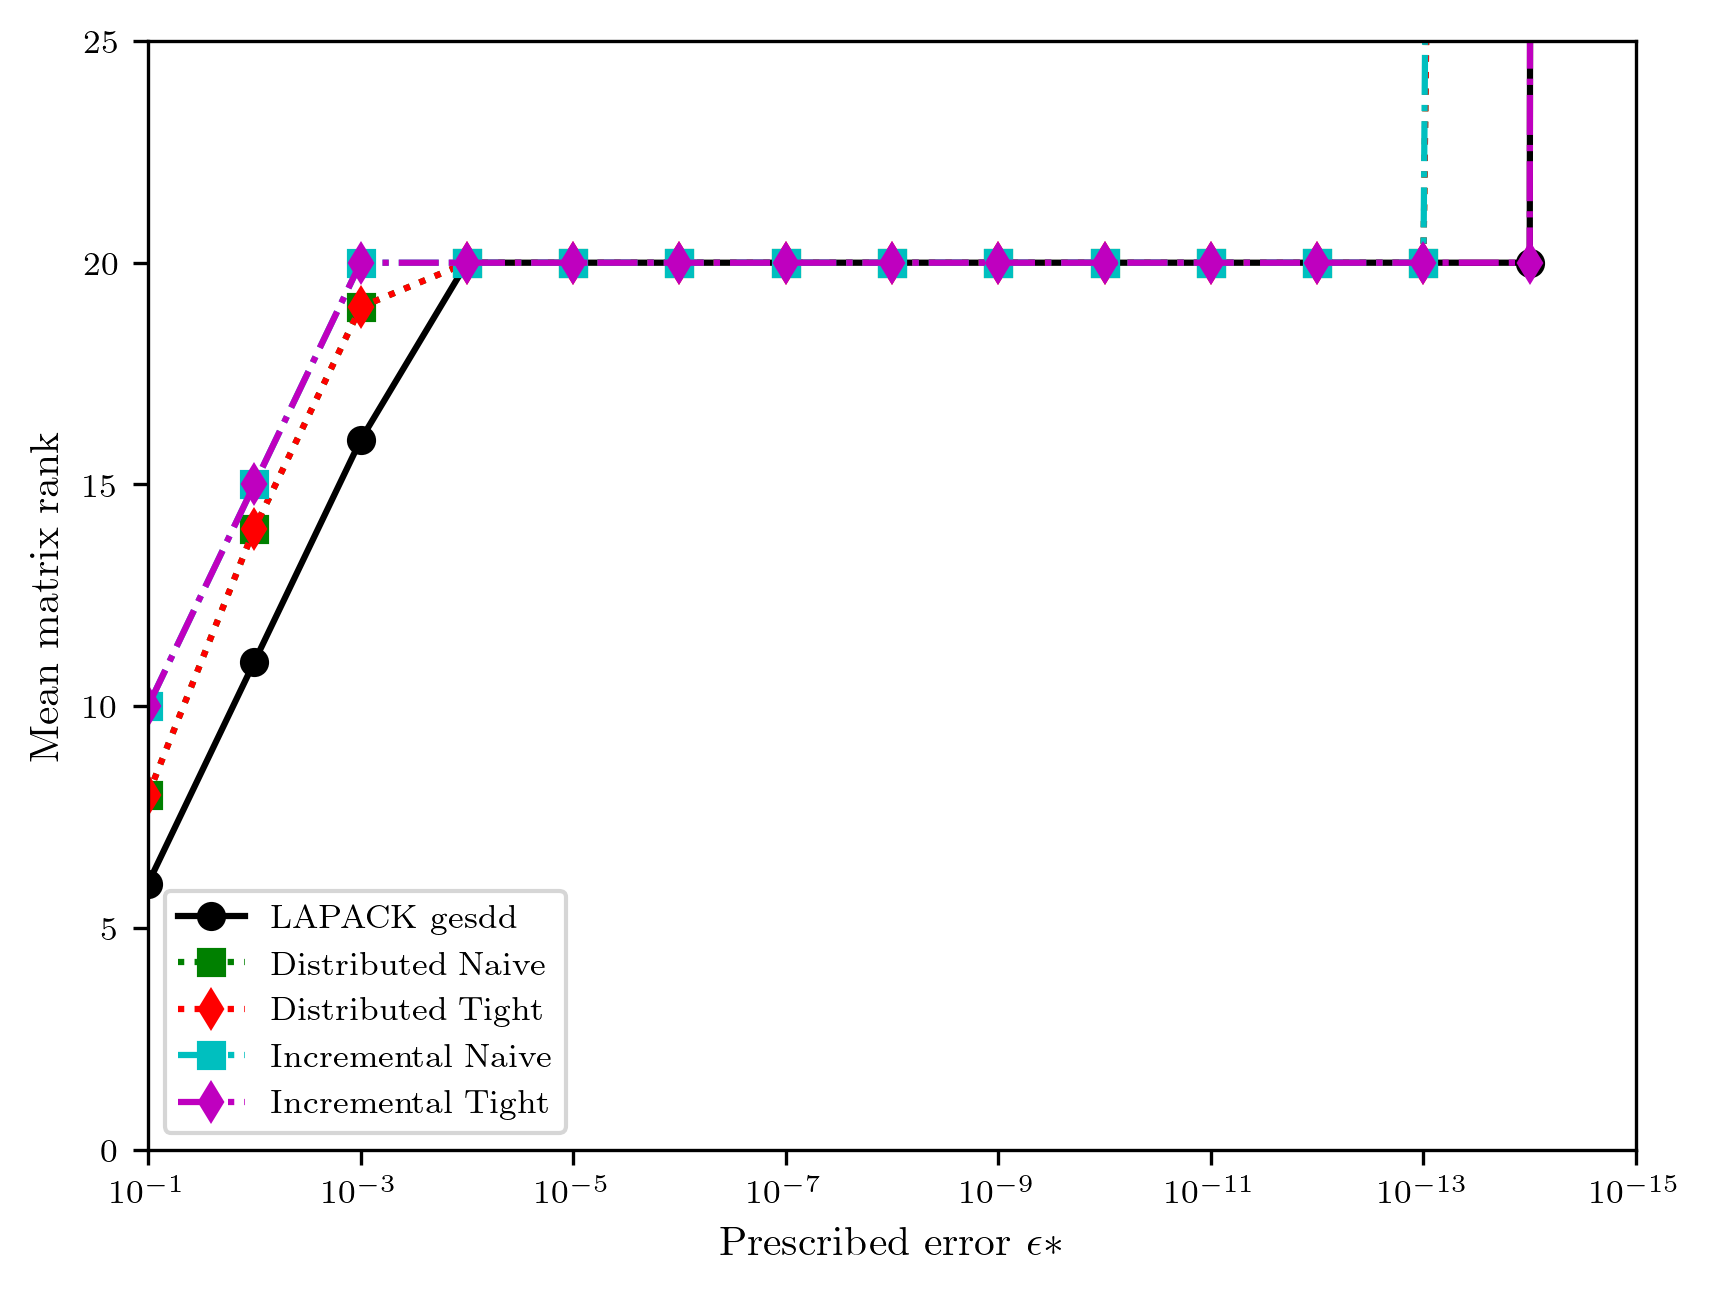

In [28]:
omega=0.1

filtered_df= df[(df["omega"]==omega)]
filtered_df=filtered_df[['eps','rk','rk_naive_0','rk_tight_0','rk_naive_1','rk_tight_1']]

# Define new labels for the plot
label_map = {
    'rk': 'LAPACK gesdd',
    'rk_naive_0': 'Distributed Naive',
    'rk_tight_0': 'Distributed Tight',
    'rk_naive_1': 'Incremental Naive',
    'rk_tight_1': 'Incremental Tight',
}

# Define styles
markers = ['o', 's', 'd', 's', 'd', '*']
colors = ['k', 'g', 'r', 'c', 'm', 'k']
linestyles = ['-', ':', ':','-.','-.', '--']

ax=None

for i, col in enumerate(['rk','rk_naive_0','rk_tight_0','rk_naive_1','rk_tight_1']):
    marker = markers[i % len(markers)]
    ax = filtered_df.plot(
        x='eps',
        marker= marker,
        y=col,
        ax=ax,
        label=label_map[col],
        color=colors[i % len(colors)],
        linestyle=linestyles[i]
    )

ax.set_xscale('log')
ax.set_xlim([1e-1,1e-15])
ax.set_ylim([0,25])
ax.set_xlabel('Prescribed error $\epsilon*$')
ax.set_ylabel('Mean matrix rank')



KeyError: 'omega'

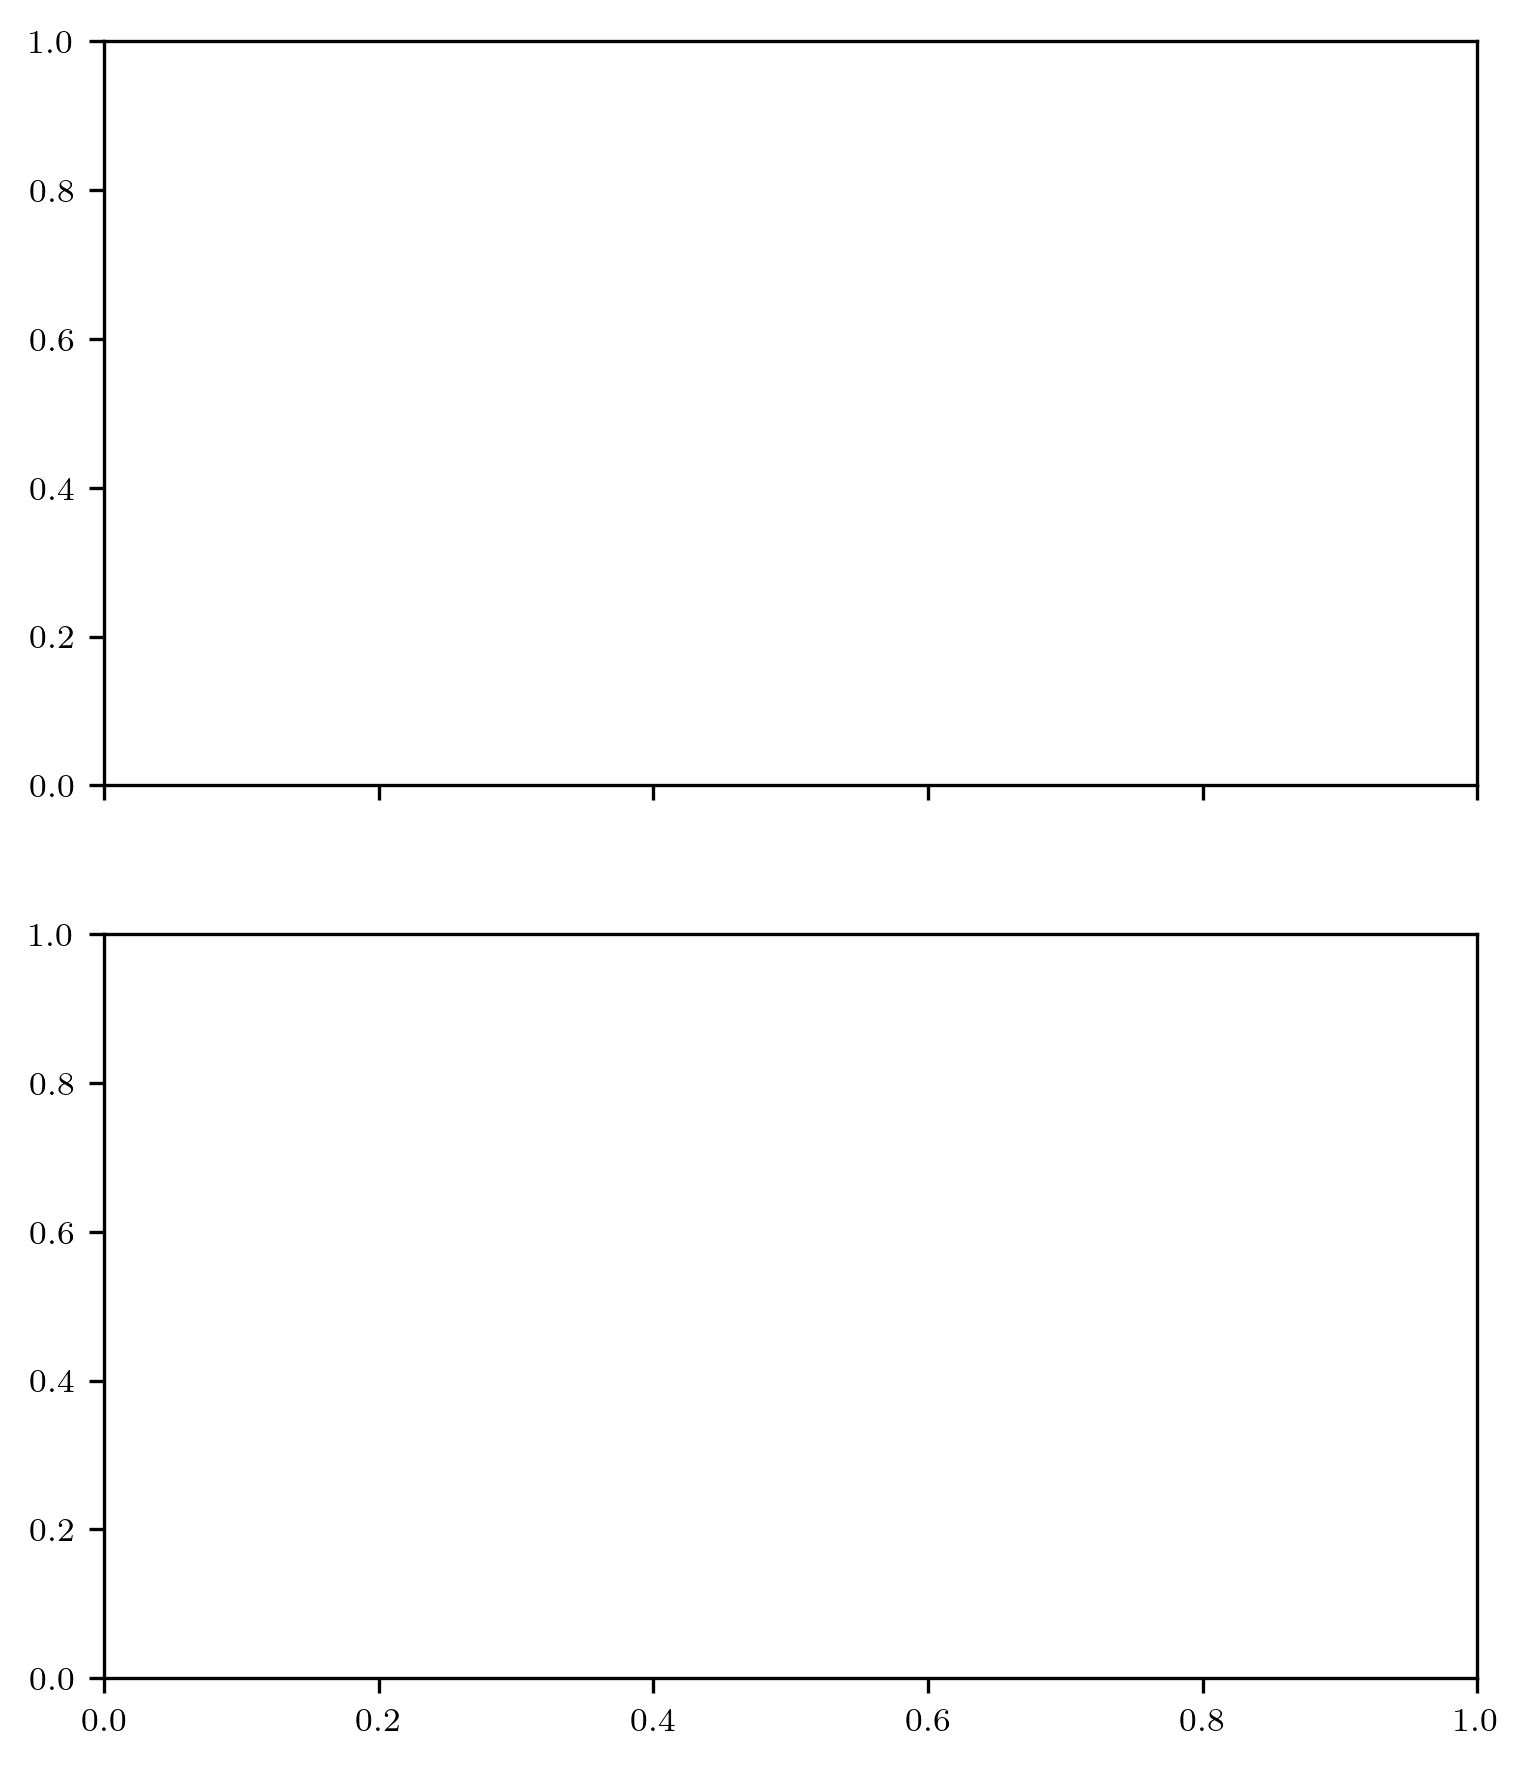

## Control parameter behavior

In [13]:
# Import the data
df = pd.read_csv('general_error_rank_data_bench_2.csv')

In [16]:
import matplotlib.pyplot as plt

# === Figure size (inches) ===
width_in = 150 / 25.4  # 150 mm
height_in = (width_in)/2 * 0.75 + 0.5

# === Thesis-style settings ===
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
})

# === Create two subplots ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width_in, height_in))

# === Styles ===
markers = ['o', 's', 'd', '^', 'v']
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = [':', '-.']

xlabel = r'Prescribed $\epsilon^*$'
ylabel_error = r'Mean Frobenius error $\epsilon$'
ylabel_rank = r'Mean matrix rank $r$'

# === Filtered data ===
filtered_df = df[['eps','omega','rk','err','err_tight_0','err_tight_1','rk_tight_0','rk_tight_1']]
omega_vals = sorted(pd.unique(filtered_df['omega']))

# === Frobenius Error Plot ===
for i, omega in enumerate(omega_vals):
    plot_df = filtered_df[filtered_df["omega"] == omega]
    ax1.plot(
        plot_df['eps'],
        plot_df['err_tight_1'],
        label=rf"$\omega={omega}$",
        color=colors[i],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i],
        linewidth=1,
        markersize=4
    )

# Add LAPACK gesdd baseline
lapack_df = filtered_df[filtered_df["omega"] == 0.1]
ax1.plot(
    lapack_df['eps'],
    lapack_df['err'],
    label=r"$SVD_{\mathrm{gesdd}}$",
    color='k',
    linestyle='-',
    linewidth=1
)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim([4e-2, 4e-4])
ax1.set_xlabel(xlabel)
ax1.set_ylabel(ylabel_error)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
#ax1.get_legend().remove()

# === Rank Plot ===
for i, omega in enumerate(omega_vals):
    plot_df = filtered_df[filtered_df["omega"] == omega]
    ax2.plot(
        plot_df['eps'],
        plot_df['rk_tight_1'],
        label=rf"$\omega={omega}$",
        color=colors[i],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i],
        linewidth=1,
        markersize=4
    )

# Add LAPACK gesdd baseline
ax2.plot(
    lapack_df['eps'],
    lapack_df['rk'],
    label=r"$SVD_{\mathrm{gesdd}}$",
    color='k',
    linestyle='-',
    linewidth=1
)

ax2.set_xscale('log')
ax2.set_xlim([4e-2, 4e-4])
ax2.set_xlabel(xlabel)
ax2.set_ylabel(ylabel_rank)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
#ax2.get_legend().remove()

# === Legend ===
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.99))

# === Layout ===
fig.tight_layout()
fig.subplots_adjust(top=0.75)

# === Subfigure labels (a), (b) ===
ax1.text(-0.15, 1.1, '(a)', transform=ax1.transAxes, fontsize=10, va='top', ha='right')
ax2.text(-0.15, 1.1, '(b)', transform=ax2.transAxes, fontsize=10, va='top', ha='right')

# === Save ===
fig.savefig("frob-rank-eps-vs-omega.pdf", format="pdf", dpi=300, transparent=True)
# Optional PGF save: fig.savefig("frob-rank-eps-vs-omega.pgf")

plt.close(fig)
